In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers   # type: ignore
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, confusion_matrix, classification_report
import pickle, json

2026-04-30 11:46:14.364857: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777549574.555602      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777549574.609923      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777549575.040450      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777549575.040485      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777549575.040488      57 computation_placer.cc:177] computation placer alr

In [2]:
# ── Colors ─────────────────────────────────────────────────────────────────────
DARK    = '#0f1117'
SURF    = '#1a1d27'
GRID    = '#2e3250'
TXT     = '#c9d1e0'
MUT     = '#7a82a0'
ACCENT  = '#4f8ef7'
ACCENT2 = '#f7614f'
ACCENT3 = '#4fcf8e'
 
def style(ax, grid_axis='both'):
    ax.set_facecolor(SURF)
    ax.tick_params(colors=MUT, labelsize=9)
    ax.xaxis.label.set_color(TXT)
    ax.yaxis.label.set_color(TXT)
    ax.title.set_color(TXT)
    for sp in ax.spines.values():
        sp.set_edgecolor(GRID)
    if grid_axis:
        ax.grid(True, color=GRID, linestyle='--', alpha=0.5, axis=grid_axis)

In [3]:
# 1. LOAD
# ══════════════════════════════════════════════════════════════════════════════
COLS = ['unit','cycle','os1','os2','os3'] + [f's{i}' for i in range(1, 22)]
 
def load_data(path):
    return pd.read_csv(path, sep=r'\s+', header=None,
                       usecols=range(26), names=COLS, engine='python')
 
BASE  = '/kaggle/input/datasets/bishals098/nasa-turbofan-engine-degradation-simulation/'
train = load_data(BASE + 'train_FD001.txt')
test  = load_data(BASE + 'test_FD001.txt')
rul   = pd.read_csv(BASE + 'RUL_FD001.txt', header=None, names=['rul'])
 
print(f"Train: {train.shape}  |  Test: {test.shape}  |  RUL entries: {len(rul)}")
print(f"Train engines: {train['unit'].nunique()}  |  Test engines: {test['unit'].nunique()}")

Train: (20631, 26)  |  Test: (13096, 26)  |  RUL entries: 100
Train engines: 100  |  Test engines: 100


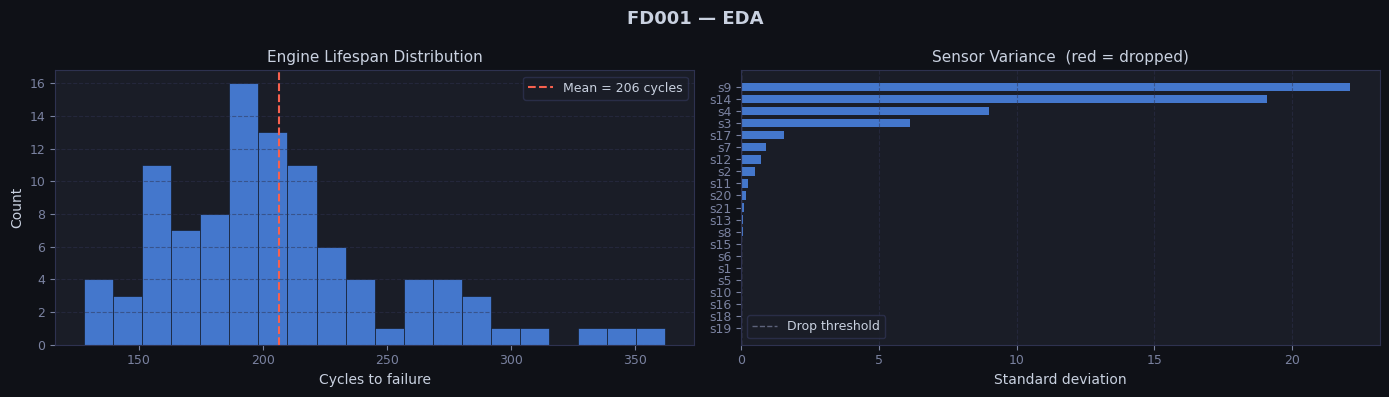

In [4]:
KEEP_SENSORS = ['s2','s3','s4','s7','s9','s11','s12','s14','s17','s20','s21']
engine_lives = train.groupby('unit')['cycle'].max()
sensor_cols  = [f's{i}' for i in range(1, 22)]
sensor_std   = train[sensor_cols].std().sort_values()
 
fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor=DARK)
fig.suptitle('FD001 — EDA', fontsize=13, color=TXT, fontweight='bold')
 
style(axes[0], grid_axis='y')
axes[0].hist(engine_lives, bins=20, color=ACCENT, alpha=0.8, edgecolor=DARK, linewidth=0.5)
axes[0].axvline(engine_lives.mean(), color=ACCENT2, lw=1.5, linestyle='--',
                label=f'Mean = {engine_lives.mean():.0f} cycles')
axes[0].set_title('Engine Lifespan Distribution', fontsize=11)
axes[0].set_xlabel('Cycles to failure')
axes[0].set_ylabel('Count')
axes[0].legend(facecolor=SURF, edgecolor=GRID, labelcolor=TXT, fontsize=9)
 
style(axes[1], grid_axis='x')
colors = [ACCENT2 if v < 0.01 else ACCENT for v in sensor_std.values]
axes[1].barh(sensor_std.index, sensor_std.values, color=colors, alpha=0.8, height=0.7)
axes[1].axvline(0.01, color=MUT, lw=1, linestyle='--', alpha=0.7, label='Drop threshold')
axes[1].set_title('Sensor Variance  (red = dropped)', fontsize=11)
axes[1].set_xlabel('Standard deviation')
axes[1].legend(facecolor=SURF, edgecolor=GRID, labelcolor=TXT, fontsize=9)
 
plt.tight_layout()
plt.show()

In [5]:
dropped = [s for s, v in sensor_std.items() if v < 0.01]
print(f"\nLifespan : min={engine_lives.min()}, max={engine_lives.max()}, mean={engine_lives.mean():.0f}")
print(f"Dropped  : {dropped}")
print(f"Kept     : {KEEP_SENSORS}")


Lifespan : min=128, max=362, mean=206
Dropped  : ['s19', 's18', 's16', 's10', 's5', 's1', 's6']
Kept     : ['s2', 's3', 's4', 's7', 's9', 's11', 's12', 's14', 's17', 's20', 's21']


In [6]:
# 3. PREPROCESSING
# ══════════════════════════════════════════════════════════════════════════════
DROP = ['s1','s5','s6','s8','s10','s13','s15','s16','s18','s19','os3']
train.drop(columns=DROP, inplace=True)
test.drop(columns=DROP,  inplace=True)

In [7]:
RUL_CLIP = 125
 
def add_rul(df):
    max_cycle = df.groupby('unit')['cycle'].transform('max')
    df['RUL'] = (max_cycle - df['cycle']).clip(upper=RUL_CLIP)
    return df
 
train = add_rul(train)
 
last_cycles        = test.groupby('unit')['cycle'].max().reset_index()
last_cycles['RUL'] = rul['rul'].values
test      = test.merge(last_cycles[['unit','RUL']], on='unit', how='left')
test_last = test.groupby('unit').last().reset_index()
 
train[KEEP_SENSORS] = train[KEEP_SENSORS].astype(float)
test[KEEP_SENSORS]  = test[KEEP_SENSORS].astype(float)
 
scaler = MinMaxScaler()
train[KEEP_SENSORS] = scaler.fit_transform(train[KEEP_SENSORS])
test[KEEP_SENSORS]  = scaler.transform(test[KEEP_SENSORS])
 
print(f"\nTrain sensors : {train[KEEP_SENSORS].min().min():.3f} – {train[KEEP_SENSORS].max().max():.3f}")
print(f"Test  sensors : {test[KEEP_SENSORS].min().min():.3f}  – {test[KEEP_SENSORS].max().max():.3f}")
print(f"Train RUL     : 0 – {train['RUL'].max()}")


Train sensors : 0.000 – 1.000
Test  sensors : -0.044  – 1.081
Train RUL     : 0 – 125


In [8]:
# 4. SEQUENCES
# ══════════════════════════════════════════════════════════════════════════════
WINDOW = 30
 
def build_sequences(df, feature_cols, window):
    X, y = [], []
    for _, eng in df.groupby('unit'):
        eng  = eng.sort_values('cycle')
        data = eng[feature_cols].values
        labs = eng['RUL'].values
        for i in range(len(data) - window + 1):
            X.append(data[i:i+window])
            y.append(labs[i+window-1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)
 
def build_last_sequences(df, feature_cols, window):
    X, y = [], []
    for _, eng in df.groupby('unit'):
        eng  = eng.sort_values('cycle')
        data = eng[feature_cols].values
        if len(data) >= window:
            X.append(data[-window:])
        else:
            pad = np.zeros((window - len(data), len(feature_cols)))
            X.append(np.vstack([pad, data]))
        y.append(eng['RUL'].iloc[-1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)
 

In [9]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, val_idx = next(gss.split(train, groups=train['unit']))
 
X_train, y_train_raw = build_sequences(train.iloc[tr_idx],  KEEP_SENSORS, WINDOW)
X_val,   y_val_raw   = build_sequences(train.iloc[val_idx], KEEP_SENSORS, WINDOW)
X_test,  y_test_raw  = build_last_sequences(test, KEEP_SENSORS, WINDOW)
 
y_train        = (y_train_raw / RUL_CLIP).astype(np.float32)
y_val          = (y_val_raw   / RUL_CLIP).astype(np.float32)
y_test_clipped = np.clip(y_test_raw, 0, RUL_CLIP).astype(np.float32)
 
print(f"\nX_train={X_train.shape} | X_val={X_val.shape} | X_test={X_test.shape}")
print(f"y_train max={y_train_raw.max():.0f}  (should be ≤{RUL_CLIP})")


X_train=(14241, 30, 11) | X_val=(3490, 30, 11) | X_test=(100, 30, 11)
y_train max=125  (should be ≤125)


In [10]:
# 5. MODEL
# ══════════════════════════════════════════════════════════════════════════════
def build_gru(window, n_features):
    inp = tf.keras.Input(shape=(window, n_features))
    x   = layers.GRU(128, return_sequences=True)(inp)
    x   = layers.Dropout(0.2)(x)
    x   = layers.GRU(64, return_sequences=True)(x)
    x   = layers.Dropout(0.2)(x)
    x   = layers.GRU(32)(x)
    x   = layers.Dropout(0.15)(x)
    x   = layers.Dense(32, activation='relu',
                       kernel_regularizer=regularizers.l2(1e-4))(x)
    x   = layers.Dense(16, activation='relu',
                       kernel_regularizer=regularizers.l2(1e-4))(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inp, out)
 

In [11]:
model = build_gru(WINDOW, len(KEEP_SENSORS))
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='mse',
    metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')]
)
model.summary()

I0000 00:00:1777549699.279957      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 11)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 30, 128)        │        54,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 30, 64)         │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,401 (400.00 KB)

 Trainable params: 102,401 (400.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
sample_weights = (1.0 + 1.5 * (y_train_raw / RUL_CLIP)).astype(np.float32)
 
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=7, min_lr=1e-6, verbose=1
    )
]

In [13]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=256,
    sample_weight=sample_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/150


I0000 00:00:1777549723.096413     151 cuda_dnn.cc:529] Loaded cuDNN version 91002


56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.2385 - rmse: 0.3386 - val_loss: 0.0381 - val_rmse: 0.1820 - learning_rate: 3.0000e-04
Epoch 2/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0708 - rmse: 0.1888 - val_loss: 0.0286 - val_rmse: 0.1540 - learning_rate: 3.0000e-04
Epoch 3/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0608 - rmse: 0.1721 - val_loss: 0.0267 - val_rmse: 0.1479 - learning_rate: 3.0000e-04
Epoch 4/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0575 - rmse: 0.1671 - val_loss: 0.0252 - val_rmse: 0.1432 - learning_rate: 3.0000e-04
Epoch 5/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0555 - rmse: 0.1645 - val_loss: 0.0201 - val_rmse: 0.1244 - learning_rate: 3.0000e-04
Epoch 6/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0436 - rmse: 0.1426 - val_loss: 0.0180 - val_rmse: 0.1162 - learning_rate: 3.0000e-04
Epoch 7/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0401 - rmse: 0.1357 - val_loss: 0.0193 - val_rmse: 0.1222 - le

In [14]:
def nasa_score(y_true, y_pred):
    d = y_pred.flatten() - y_true.flatten()
    return float(np.sum(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1)))
 
val_preds  = model.predict(X_val).flatten()  * RUL_CLIP
test_preds = np.clip(model.predict(X_test).flatten() * RUL_CLIP, 0, RUL_CLIP)
 
rmse_val  = np.sqrt(mean_squared_error(y_val_raw,      val_preds))
rmse_test = np.sqrt(mean_squared_error(y_test_clipped, test_preds))
nasa      = nasa_score(y_test_clipped, test_preds)
 
results = pd.DataFrame({
    'unit':      test_last['unit'].values,
    'true_RUL':  y_test_clipped,
    'pred_RUL':  test_preds,
    'error':     test_preds - y_test_clipped,
    'abs_error': np.abs(test_preds - y_test_clipped)
})
 
bins   = [0, 30, 60, 90, 125]
labels = ['critical(0-30)', 'degrading(30-60)', 'mid(60-90)', 'healthy(90-125)']
results['bucket']        = pd.cut(results['true_RUL'], bins=bins, labels=labels)
results['critical_true'] = results['true_RUL'] < 30
results['critical_pred'] = results['pred_RUL'] < 30
 
bucket_stats = results.groupby('bucket', observed=True)['abs_error'].agg(['mean','count']).round(2)
 
print(f"\n  Val RMSE   {rmse_val:.2f} cycles")
print(f"  Test RMSE  {rmse_test:.2f} cycles")
print(f"  NASA Score {nasa:.0f}\n")
print(f"=== Error by bucket ===\n{bucket_stats}\n")
print(classification_report(results['critical_true'], results['critical_pred'],
                             target_names=['safe','critical']))

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

  Val RMSE   12.60 cycles
  Test RMSE  14.85 cycles
  NASA Score 437

=== Error by bucket ===
                   mean  count
bucket                        
critical(0-30)     2.41     25
degrading(30-60)   8.24     14
mid(60-90)        26.24     15
healthy(90-125)   10.19     46

              precision    recall  f1-score   support

        safe       0.96      0.99      0.97        75
    critical       0.96      0.88      0.92        25

    accuracy                           0.96       100
   macro avg       0.96      0.93      0.95       100
weighted avg       0.96      0.96      0.96       100



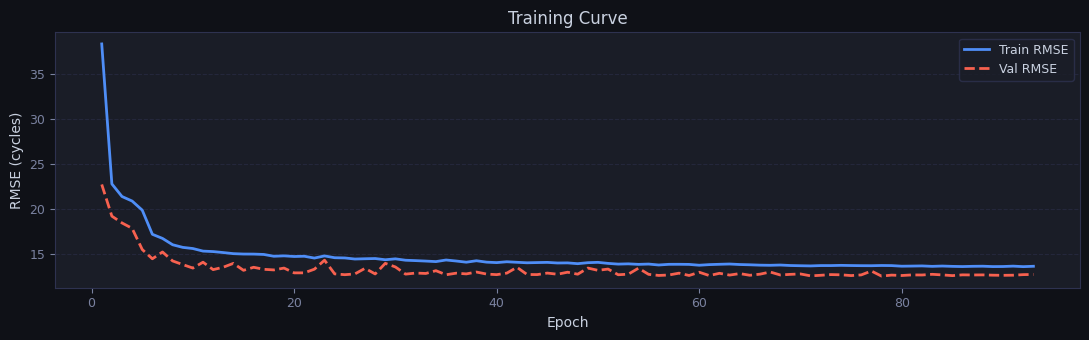

In [15]:
# ── Plot 1: Training curve ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 3.5), facecolor=DARK)
style(ax, grid_axis='y')
ep = range(1, len(history.history['rmse']) + 1)
ax.plot(ep, np.array(history.history['rmse'])     * RUL_CLIP,
        color=ACCENT,  lw=2, label='Train RMSE')
ax.plot(ep, np.array(history.history['val_rmse']) * RUL_CLIP,
        color=ACCENT2, lw=2, label='Val RMSE', linestyle='--')
ax.set_title('Training Curve', fontsize=12)
ax.set_xlabel('Epoch')
ax.set_ylabel('RMSE (cycles)')
ax.legend(facecolor=SURF, edgecolor=GRID, labelcolor=TXT, fontsize=9)
plt.tight_layout()
plt.show()

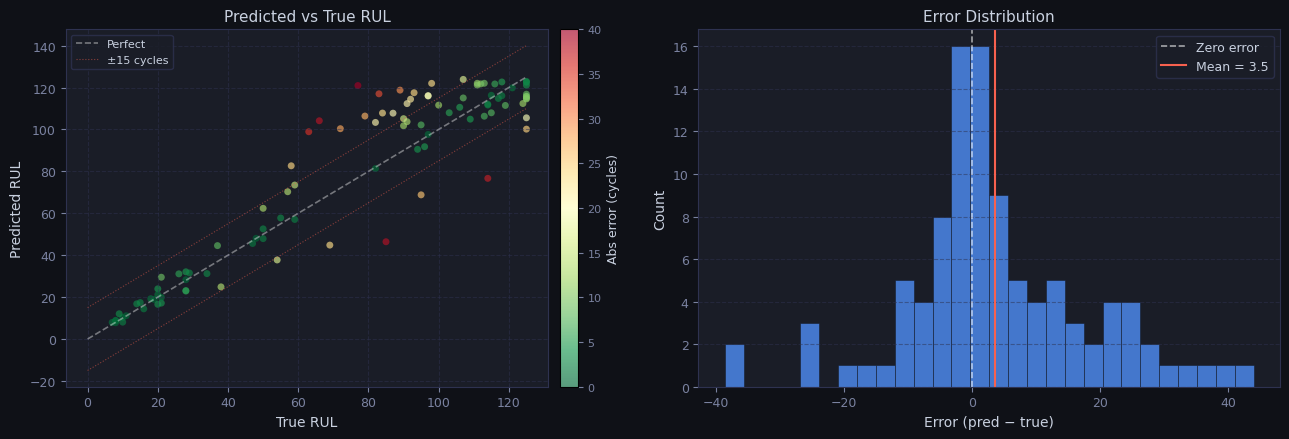

In [16]:
# ── Plot 2: Predicted vs True  +  Error histogram ─────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), facecolor=DARK)
style(ax1); style(ax2, grid_axis='y')
 
sc = ax1.scatter(results['true_RUL'], results['pred_RUL'],
                 c=results['abs_error'], cmap='RdYlGn_r',
                 alpha=0.65, s=25, edgecolors='none', vmin=0, vmax=40)
ax1.plot([0,125],[0,125],   color='white', lw=1.2, linestyle='--', alpha=0.4, label='Perfect')
ax1.plot([0,125],[15,140],  color=ACCENT2, lw=0.8, linestyle=':',  alpha=0.5, label='±15 cycles')
ax1.plot([0,125],[-15,110], color=ACCENT2, lw=0.8, linestyle=':',  alpha=0.5)
cbar = plt.colorbar(sc, ax=ax1, pad=0.02)
cbar.ax.tick_params(colors=MUT, labelsize=8)
cbar.set_label('Abs error (cycles)', color=TXT, fontsize=9)
ax1.set_title('Predicted vs True RUL', fontsize=11)
ax1.set_xlabel('True RUL')
ax1.set_ylabel('Predicted RUL')
ax1.legend(facecolor=SURF, edgecolor=GRID, labelcolor=TXT, fontsize=8)
 
ax2.hist(results['error'], bins=28, color=ACCENT, alpha=0.8, edgecolor=DARK, linewidth=0.4)
ax2.axvline(0, color='white', lw=1.2, linestyle='--', alpha=0.6, label='Zero error')
ax2.axvline(results['error'].mean(), color=ACCENT2, lw=1.5,
            label=f'Mean = {results["error"].mean():.1f}')
ax2.set_title('Error Distribution', fontsize=11)
ax2.set_xlabel('Error (pred − true)')
ax2.set_ylabel('Count')
ax2.legend(facecolor=SURF, edgecolor=GRID, labelcolor=TXT, fontsize=9)
plt.tight_layout()
plt.show()

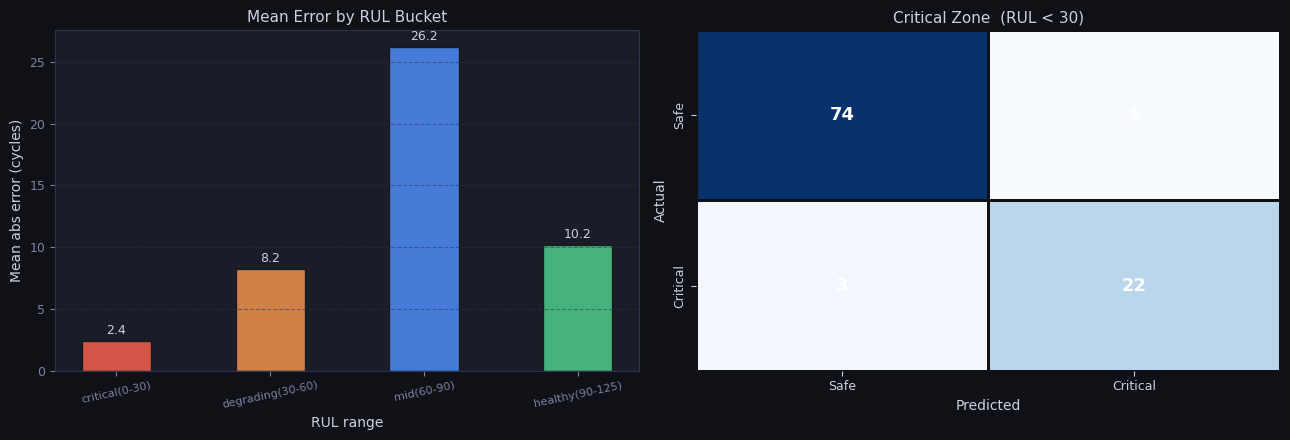

In [17]:
# ── Plot 3: Bucket error  +  Confusion matrix ─────────────────────────────────
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(13, 4.5), facecolor=DARK)
style(ax3, grid_axis='y')
ax4.set_facecolor(SURF)
 
bucket_colors = [ACCENT2, '#f0944d', ACCENT, ACCENT3]
bars = ax3.bar(bucket_stats.index.astype(str), bucket_stats['mean'],
               color=bucket_colors, alpha=0.85, edgecolor=DARK, width=0.45)
for bar, val in zip(bars, bucket_stats['mean']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}', ha='center', va='bottom', fontsize=9, color=TXT)
ax3.set_title('Mean Error by RUL Bucket', fontsize=11)
ax3.set_xlabel('RUL range')
ax3.set_ylabel('Mean abs error (cycles)')
ax3.tick_params(axis='x', rotation=12, labelsize=8)
 
cm = confusion_matrix(results['critical_true'], results['critical_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=['Safe','Critical'],
            yticklabels=['Safe','Critical'],
            linewidths=1, linecolor=DARK,
            annot_kws={'size': 13, 'weight': 'bold', 'color': 'white'},
            cbar=False)
ax4.set_title('Critical Zone  (RUL < 30)', fontsize=11, color=TXT)
ax4.set_xlabel('Predicted', color=TXT)
ax4.set_ylabel('Actual', color=TXT)
ax4.tick_params(colors=TXT, labelsize=9)
for sp in ax4.spines.values():
    sp.set_edgecolor(GRID)
 
plt.tight_layout()
plt.show()

In [ ]:
# 9. SAVE ARTIFACTS
model.save('gru_fd001.keras')
 
with open('scaler_fd001.pkl', 'wb') as f:
    pickle.dump(scaler, f)
 
config = {
    'window':     WINDOW,
    'rul_clip':   RUL_CLIP,
    'features':   KEEP_SENSORS,
    'n_features': len(KEEP_SENSORS),
    'dataset':    'FD001',
}
with open('inference_config.json', 'w') as f:
    json.dump(config, f, indent=2)
 
print("Saved: gru_fd001.keras | scaler_fd001.pkl | inference_config.json")